# Run-Visualisierung (deutsch)

Rendert die Diagramme eines Runs neu — inhaltlich identisch zu denen, die der
Prototyp selbst erzeugt (`src/reporting/run_visualizer.py`), aber vollstaendig
auf Deutsch beschriftet und mit einer zusaetzlichen Aufteilung:

| Datei | Inhalt |
|---|---|
| `run_zusammenfassung.png` | Verteilung der Gesamtscores + Mittelwert je Dimension |
| `run_gesamtscore_je_datei.png` | Gesamtscore je Datei |
| `run_indikator_ergebnisse.png` | Indikator-Ergebnisse je Dimension (gestapelt) |
| `run_scores_je_datei_<dimension>.png` | **eine PNG pro Dimension** — bei vier aktiven Dimensionen also vier Dateien |

Der Prototyp packt die Pro-Dimension-Scores in *ein* Bild mit Subplots; hier wird
daraus je Dimension eine eigene PNG, damit die Diagramme einzeln in die Arbeit
eingebunden werden koennen.

**Eingabe:** nur die Variable `RUN` in der naechsten Zelle setzen (Run-Name oder Pfad).
Geschrieben wird in einen Unterordner des Runs — die PNGs des Prototyps bleiben unangetastet.

In [25]:
# ---------------------------------------------------------------------------
# EINGABE: Run-Name (Ordner unterhalb von run_outputs/) oder ein vollstaendiger Pfad.
# ---------------------------------------------------------------------------
RUN = "run_2026-07-13_13-21-40_state-evaluation-final_EVAL_sonnet4-5"

# Unterordner im Run, in den die deutschen PNGs geschrieben werden.
AUSGABE_ORDNER = "visualisierung_de"

In [26]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

# Repo-Root relativ zum Notebook (playground/notebooks -> ../../)
REPO_ROOT = Path.cwd().parents[1]
RUNS_DIR = REPO_ROOT / "run_outputs"

run_dir = Path(RUN) if Path(RUN).is_absolute() else RUNS_DIR / RUN
if not run_dir.is_dir():
    raise FileNotFoundError(f"Run-Ordner nicht gefunden: {run_dir}")

aggregate = json.loads((run_dir / "run_aggregate.json").read_text(encoding="utf-8"))
files = aggregate.get("files") or {}
if not files:
    raise ValueError(f"Keine Datei-Ergebnisse in {run_dir / 'run_aggregate.json'}")

out_dir = run_dir / AUSGABE_ORDNER
out_dir.mkdir(parents=True, exist_ok=True)

geschrieben: list[Path] = []

print(f"Run        : {run_dir.name}")
print(f"Dateien    : {len(files)}")
print(f"Ausgabe    : {out_dir}")

Run        : run_2026-07-13_13-21-40_state-evaluation-final_EVAL_sonnet4-5
Dateien    : 50
Ausgabe    : /home/lbuerger/masterthesis/master_thesis_prototype/run_outputs/run_2026-07-13_13-21-40_state-evaluation-final_EVAL_sonnet4-5/visualisierung_de


In [27]:
# Deutsche Beschriftungen + Palette. Farben und Diagrammformen sind bewusst
# identisch zu src/reporting/run_visualizer.py, damit die Bilder neben den
# Original-PNGs des Prototyps konsistent aussehen.

DIMENSION_DE = {
    "findability": "Auffindbarkeit",
    "accessibility": "Zugänglichkeit",
    "reusability": "Wiederverwendbarkeit",
    "expressiveness": "Aussagekraft",
    "unknown": "Unbekannt",
}
# Dateinamen-Slug je Dimension (ASCII, damit die PNG-Namen portabel bleiben).
DIMENSION_SLUG = {
    "findability": "auffindbarkeit",
    "accessibility": "zugaenglichkeit",
    "reusability": "wiederverwendbarkeit",
    "expressiveness": "aussagekraft",
    "unknown": "unbekannt",
}
STATUS_DE = {
    "pass": "bestanden",
    "partial": "teilweise",
    "fail": "nicht bestanden",
    "error": "Fehler",
}
STATUS_ORDER = ["pass", "partial", "fail", "error"]
STATUS_COLORS = {
    "pass": "#4c9f70",
    "partial": "#e2b13c",
    "fail": "#c0504d",
    "error": "#7f7f7f",
}
BALKEN = "#4c72b0"
AKZENT = "#c0504d"
MITTEL = "#4c9f70"


def dim_de(dim: str) -> str:
    return DIMENSION_DE.get(dim, dim)


def dim_slug(dim: str) -> str:
    return DIMENSION_SLUG.get(dim, dim.lower())


def dims_sortiert(dims) -> list[str]:
    # Nach deutschem Namen sortieren, nicht nach dem englischen Schluessel -
    # sonst steht in einem deutschen Diagramm eine scheinbar wahllose Reihenfolge.
    return sorted(dims, key=dim_de)


def kuerzen(name: str, limit: int = 28) -> str:
    return name if len(name) <= limit else name[: limit - 1] + "…"


def raster(n: int) -> tuple[int, int]:
    if n <= 1:
        return 1, 1
    if n == 2:
        return 1, 2
    if n <= 4:
        return 2, 2
    return math.ceil(n / 2), 2


def speichern(fig, name: str) -> Path:
    pfad = out_dir / name
    fig.savefig(pfad, dpi=150)
    geschrieben.append(pfad)
    print(f"geschrieben: {pfad.relative_to(REPO_ROOT)}")
    return pfad


dimensionen = dims_sortiert({d for e in files.values() for d in (e.get("dimension_scores") or {})})
datei_namen = sorted(files.keys())

# Indikator-IDs -> deutsche Namen. Die run_aggregate.json fuehrt nur die IDs,
# die Klarnamen stehen in den result.json der einzelnen Dateien.
indikator_namen: dict[str, str] = {}
for result_path in run_dir.glob("*/result.json"):
    try:
        result = json.loads(result_path.read_text(encoding="utf-8"))
    except (json.JSONDecodeError, OSError):
        continue
    for block in (result.get("by_dimension") or {}).values():
        for ind in block.get("indicators") or []:
            iid, name = ind.get("indicator_id"), ind.get("name_de")
            if iid and name:
                indikator_namen.setdefault(iid, name)

print(f"Dimensionen: {', '.join(dim_de(d) for d in dimensionen)}")
print(f"Indikator-Klarnamen gefunden: {len(indikator_namen)}")

Dimensionen: Auffindbarkeit, Aussagekraft, Wiederverwendbarkeit, Zugänglichkeit
Indikator-Klarnamen gefunden: 27


geschrieben: run_outputs/run_2026-07-13_13-21-40_state-evaluation-final_EVAL_sonnet4-5/visualisierung_de/run_zusammenfassung.png


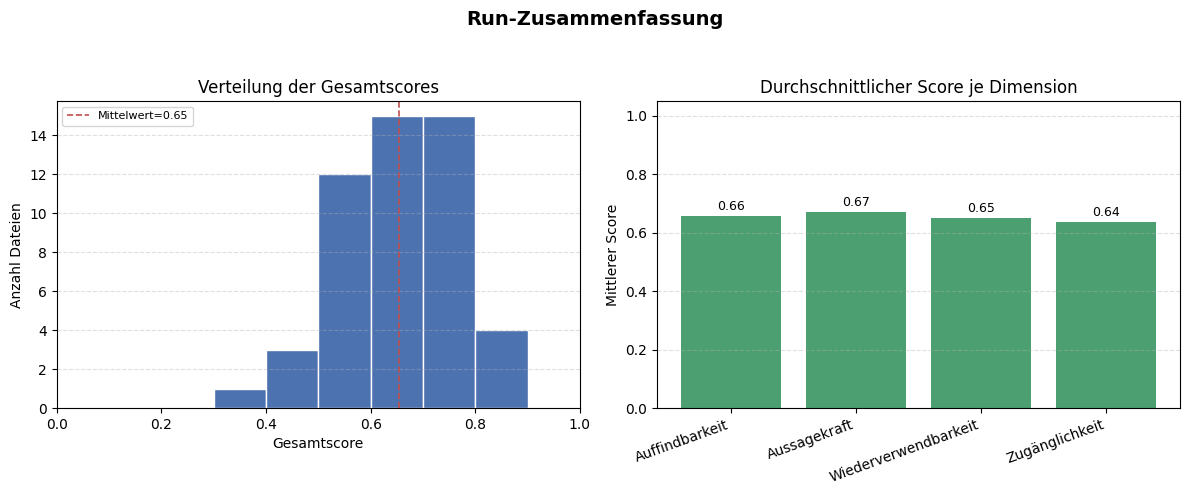

In [28]:
# 1/4 — Zusammenfassung: Verteilung der Gesamtscores + Mittelwert je Dimension.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Run-Zusammenfassung", fontsize=14, fontweight="bold")

ax = axes[0]
scores = [f["overall_score"] for f in files.values() if isinstance(f.get("overall_score"), (int, float))]
ax.set_title("Verteilung der Gesamtscores")
ax.set_xlabel("Gesamtscore")
ax.set_ylabel("Anzahl Dateien")
ax.hist(scores, bins=np.linspace(0, 1, 11), color=BALKEN, edgecolor="white")
ax.set_xlim(0, 1)
ax.axvline(float(np.mean(scores)), color=AKZENT, linestyle="--", linewidth=1.2,
           label=f"Mittelwert={np.mean(scores):.2f}")
ax.legend(loc="upper left", fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.4)

ax = axes[1]
dim_means = (aggregate.get("aggregate") or {}).get("dimension_score_means") or {}
ax.set_title("Durchschnittlicher Score je Dimension")
ax.set_ylabel("Mittlerer Score")
ax.set_ylim(0, 1.05)
dims = dims_sortiert(dim_means)
werte = [dim_means.get(d) or 0.0 for d in dims]
bars = ax.bar(np.arange(len(dims)), werte, color=MITTEL)
for bar, wert in zip(bars, werte):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{wert:.2f}",
            ha="center", fontsize=9)
ax.set_xticks(np.arange(len(dims)))
ax.set_xticklabels([dim_de(d) for d in dims], rotation=20, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.tight_layout(rect=(0, 0, 1, 0.94))
speichern(fig, "run_zusammenfassung.png")
plt.show()

geschrieben: run_outputs/run_2026-07-13_13-21-40_state-evaluation-final_EVAL_sonnet4-5/visualisierung_de/run_gesamtscore_je_datei.png


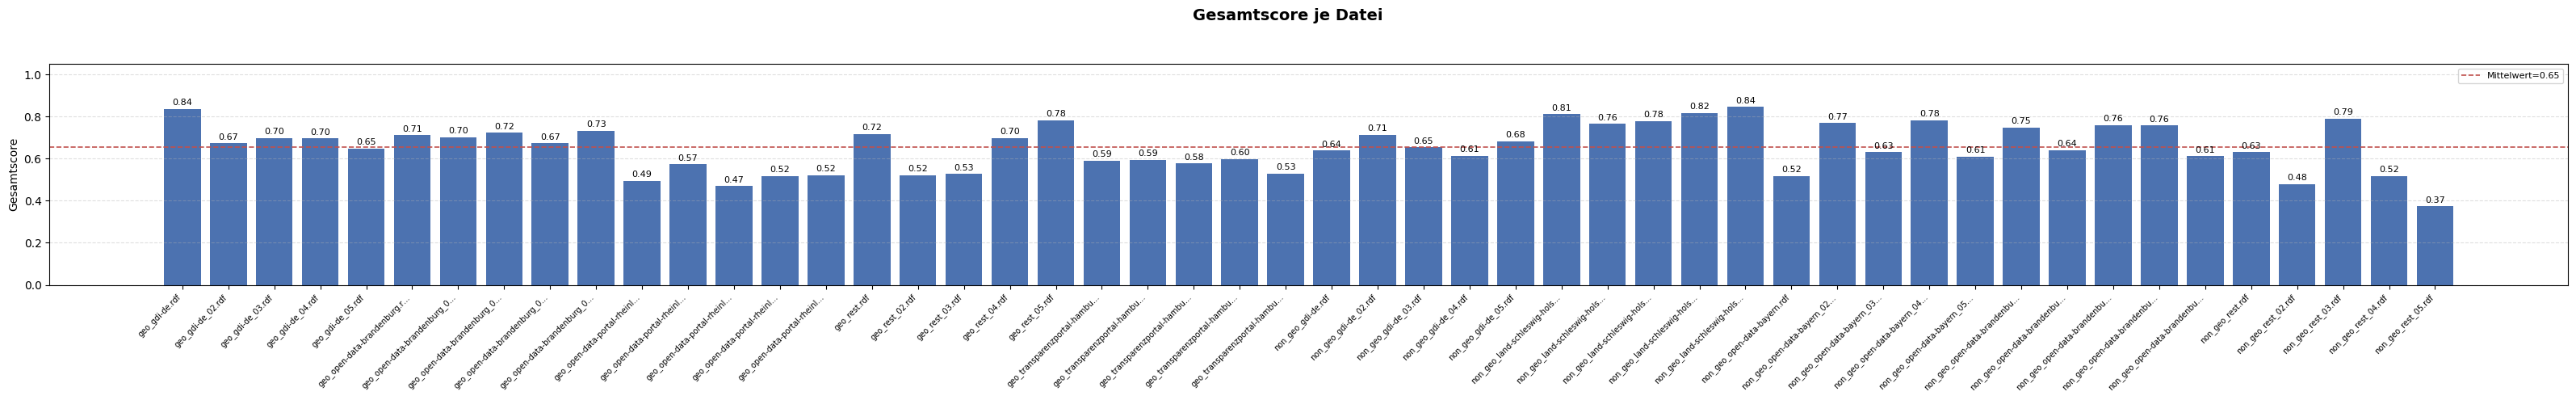

In [29]:
# 2/4 — Gesamtscore je Datei.
bewertet = {n: e["overall_score"] for n, e in files.items() if isinstance(e.get("overall_score"), (int, float))}
namen = sorted(bewertet)
werte = [float(bewertet[n]) for n in namen]

# Breite waechst mit der Dateianzahl, damit Balken und Labels lesbar bleiben.
breite = max(8.0, 0.6 * len(namen) + 2.0)
fig, ax = plt.subplots(figsize=(breite, 5))
fig.suptitle("Gesamtscore je Datei", fontsize=14, fontweight="bold")

x = np.arange(len(namen))
bars = ax.bar(x, werte, color=BALKEN)
for bar, wert in zip(bars, werte):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{wert:.2f}",
            ha="center", va="bottom", fontsize=8)

mittel = float(np.mean(werte))
ax.axhline(mittel, color=AKZENT, linestyle="--", linewidth=1.2, label=f"Mittelwert={mittel:.2f}")
ax.set_ylabel("Gesamtscore")
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels([kuerzen(n) for n in namen], rotation=45, ha="right", fontsize=7)
ax.legend(loc="upper right", fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.tight_layout(rect=(0, 0, 1, 0.94))
speichern(fig, "run_gesamtscore_je_datei.png")
plt.show()

geschrieben: run_outputs/run_2026-07-13_13-21-40_state-evaluation-final_EVAL_sonnet4-5/visualisierung_de/run_indikator_ergebnisse.png


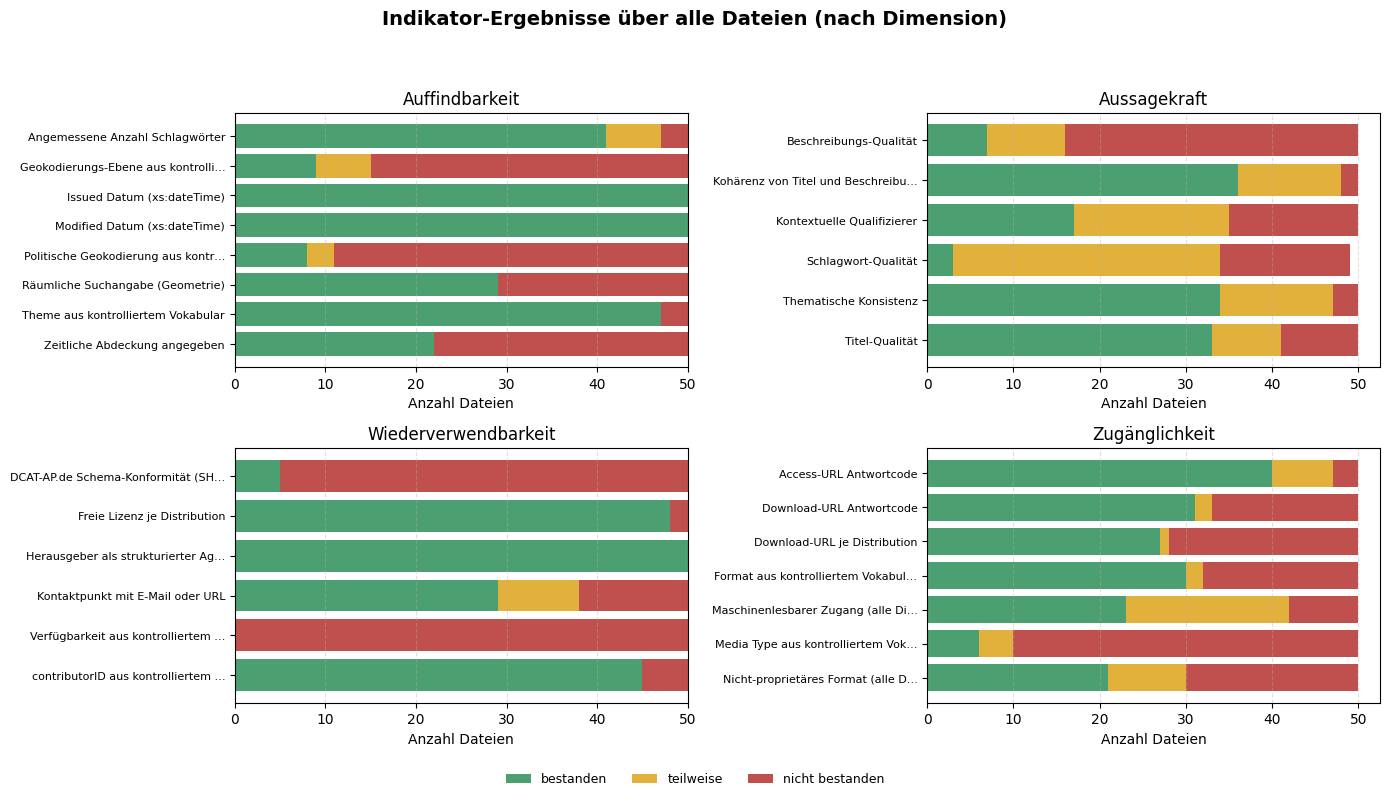

In [30]:
# 3/4 — Indikator-Ergebnisse ueber alle Dateien, je Dimension ein Subplot.
counts = (aggregate.get("aggregate") or {}).get("indicator_status_counts") or {}

nach_dim: dict[str, dict[str, dict]] = {}
for iid, c in counts.items():
    nach_dim.setdefault(c.get("dimension") or "unknown", {})[iid] = c

dims = dims_sortiert(nach_dim)
rows, cols = raster(len(dims))
fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 4 * rows), squeeze=False)
fig.suptitle("Indikator-Ergebnisse über alle Dateien (nach Dimension)", fontsize=14, fontweight="bold")

# Ein Status -> ein Legendeneintrag, egal in wie vielen Subplots er vorkommt.
legende: dict[str, object] = {}

for idx, dim in enumerate(dims):
    ax = axes[idx // cols][idx % cols]
    ax.set_title(dim_de(dim))
    ax.set_xlabel("Anzahl Dateien")

    ids = sorted(nach_dim[dim], key=lambda i: indikator_namen.get(i, i))
    y = np.arange(len(ids))
    links = np.zeros(len(ids))
    for status in STATUS_ORDER:
        werte = np.array([nach_dim[dim][i].get(status, 0) for i in ids], dtype=float)
        if werte.sum() == 0:
            continue
        balken = ax.barh(y, werte, left=links, color=STATUS_COLORS[status])
        legende.setdefault(STATUS_DE[status], balken)
        links += werte

    ax.set_yticks(y)
    # Klarname statt technischer ID, sofern aus den result.json bekannt.
    ax.set_yticklabels([kuerzen(indikator_namen.get(i, i), 34) for i in ids], fontsize=8)
    ax.invert_yaxis()
    ax.grid(axis="x", linestyle="--", alpha=0.4)

for idx in range(len(dims), rows * cols):
    axes[idx // cols][idx % cols].set_axis_off()

# Gemeinsame Legende unter der Grafik: eine Legende pro Subplot verdeckte sonst
# genau die Balken, die sie erklaeren soll.
fig.legend(legende.values(), legende.keys(), loc="lower center",
           ncol=len(legende), fontsize=9, frameon=False)

fig.tight_layout(rect=(0, 0.04, 1, 0.94))
speichern(fig, "run_indikator_ergebnisse.png")
plt.show()

geschrieben: run_outputs/run_2026-07-13_13-21-40_state-evaluation-final_EVAL_sonnet4-5/visualisierung_de/run_scores_je_datei_auffindbarkeit.png


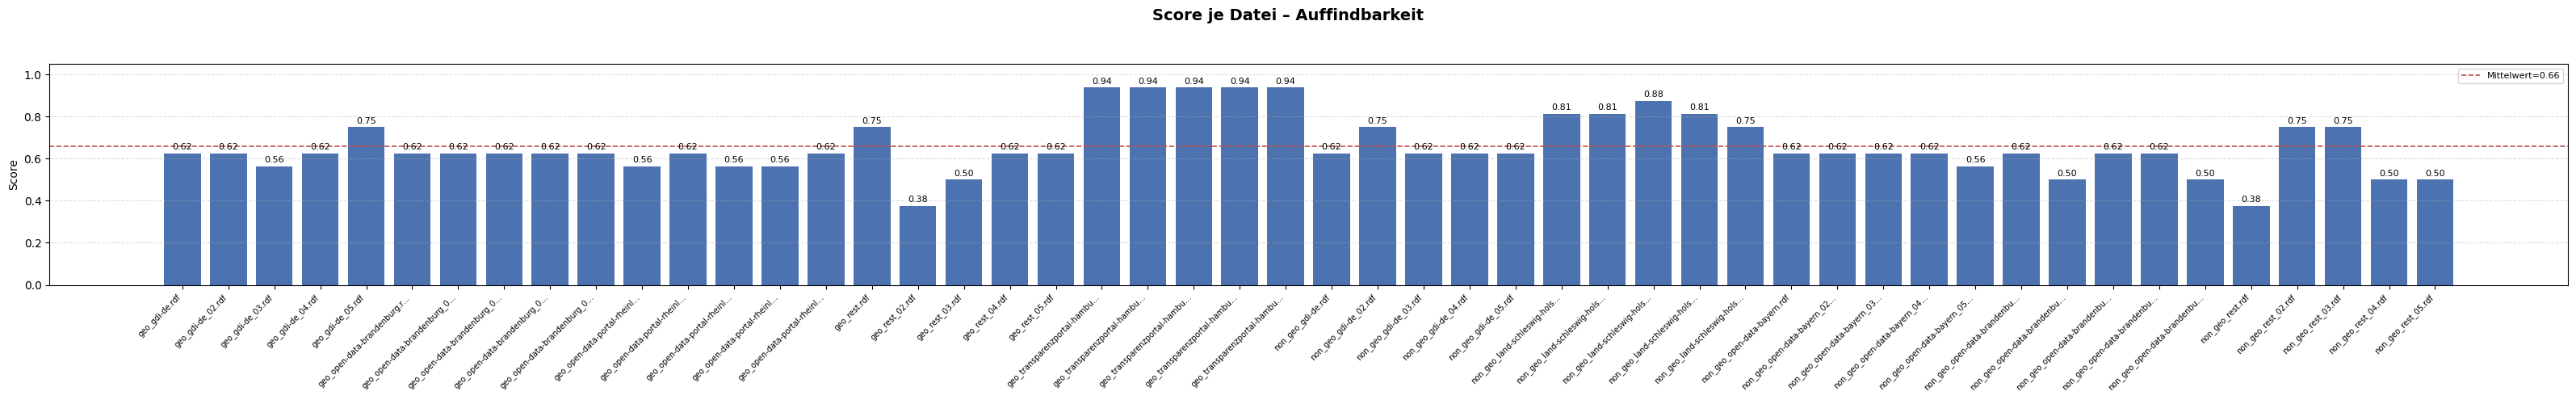

geschrieben: run_outputs/run_2026-07-13_13-21-40_state-evaluation-final_EVAL_sonnet4-5/visualisierung_de/run_scores_je_datei_aussagekraft.png


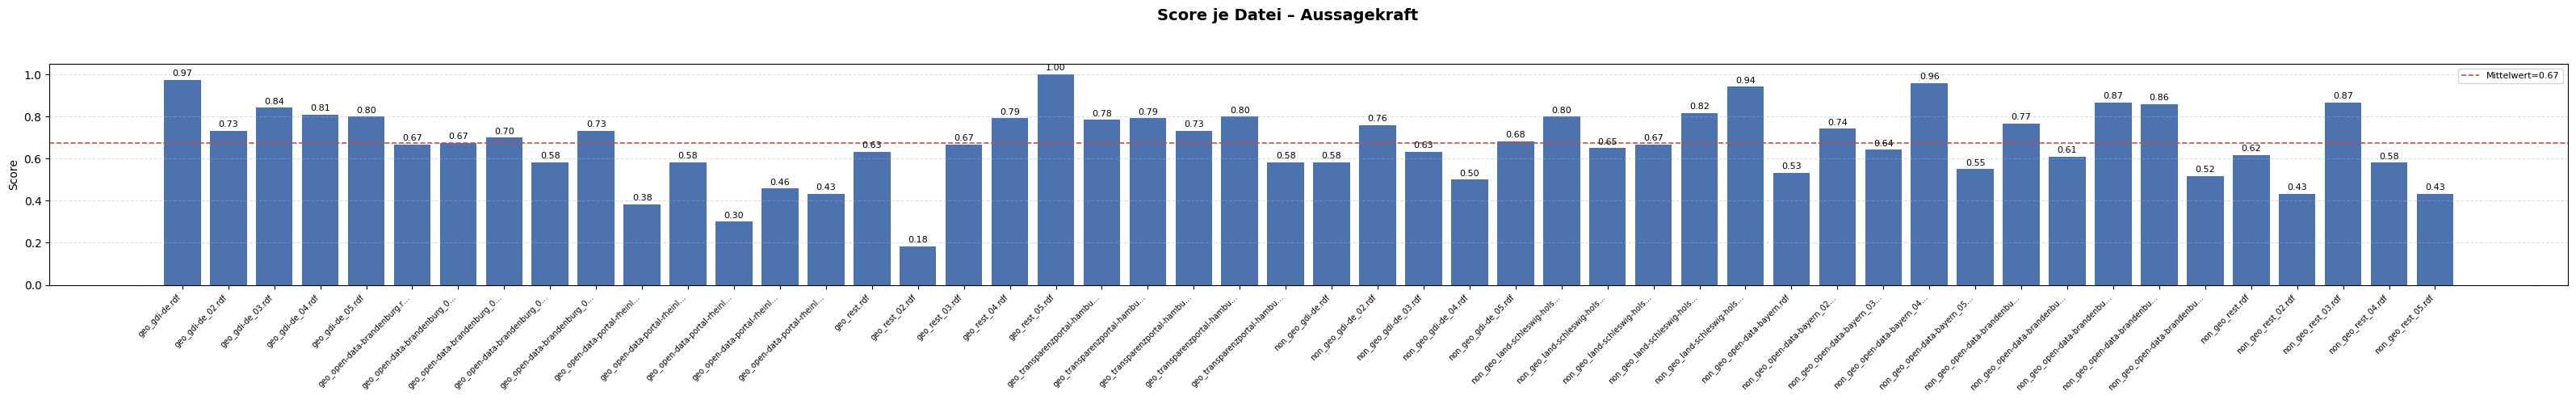

geschrieben: run_outputs/run_2026-07-13_13-21-40_state-evaluation-final_EVAL_sonnet4-5/visualisierung_de/run_scores_je_datei_wiederverwendbarkeit.png


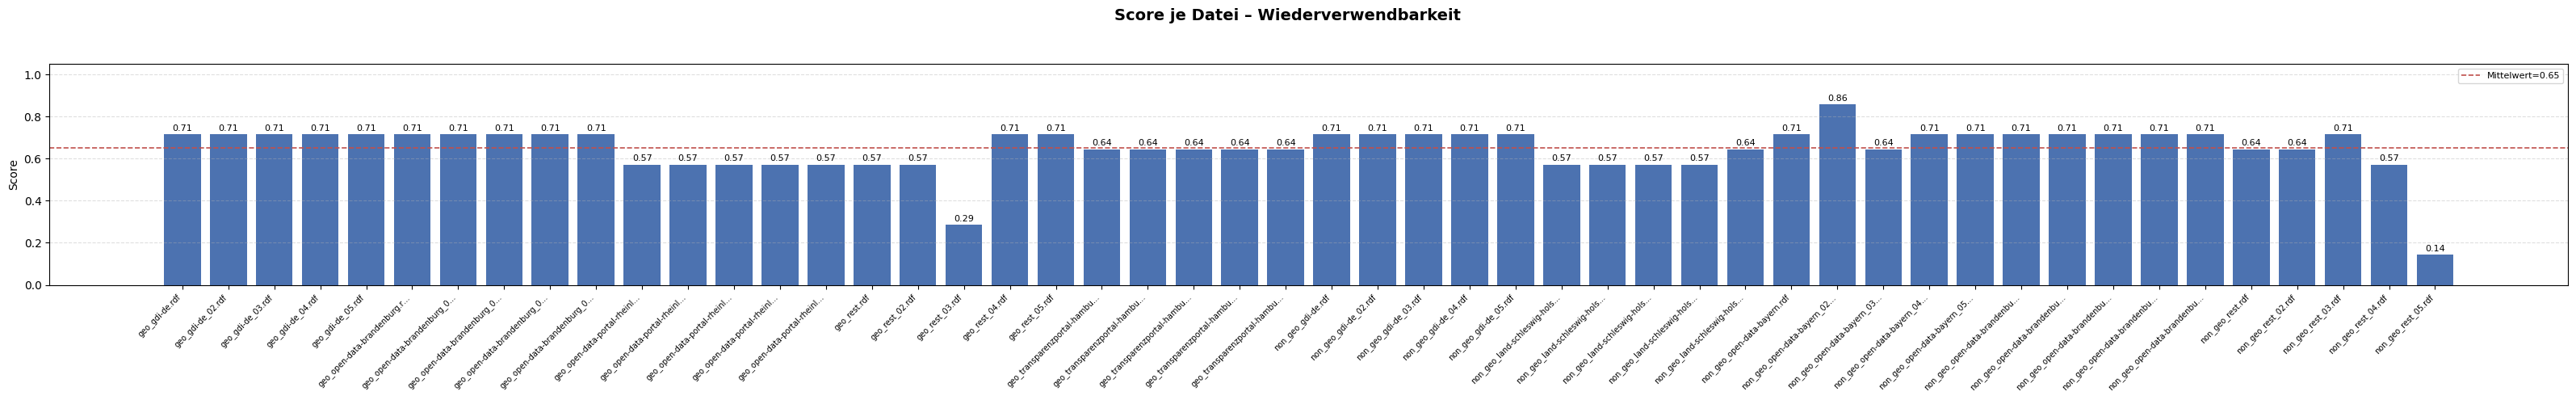

geschrieben: run_outputs/run_2026-07-13_13-21-40_state-evaluation-final_EVAL_sonnet4-5/visualisierung_de/run_scores_je_datei_zugaenglichkeit.png


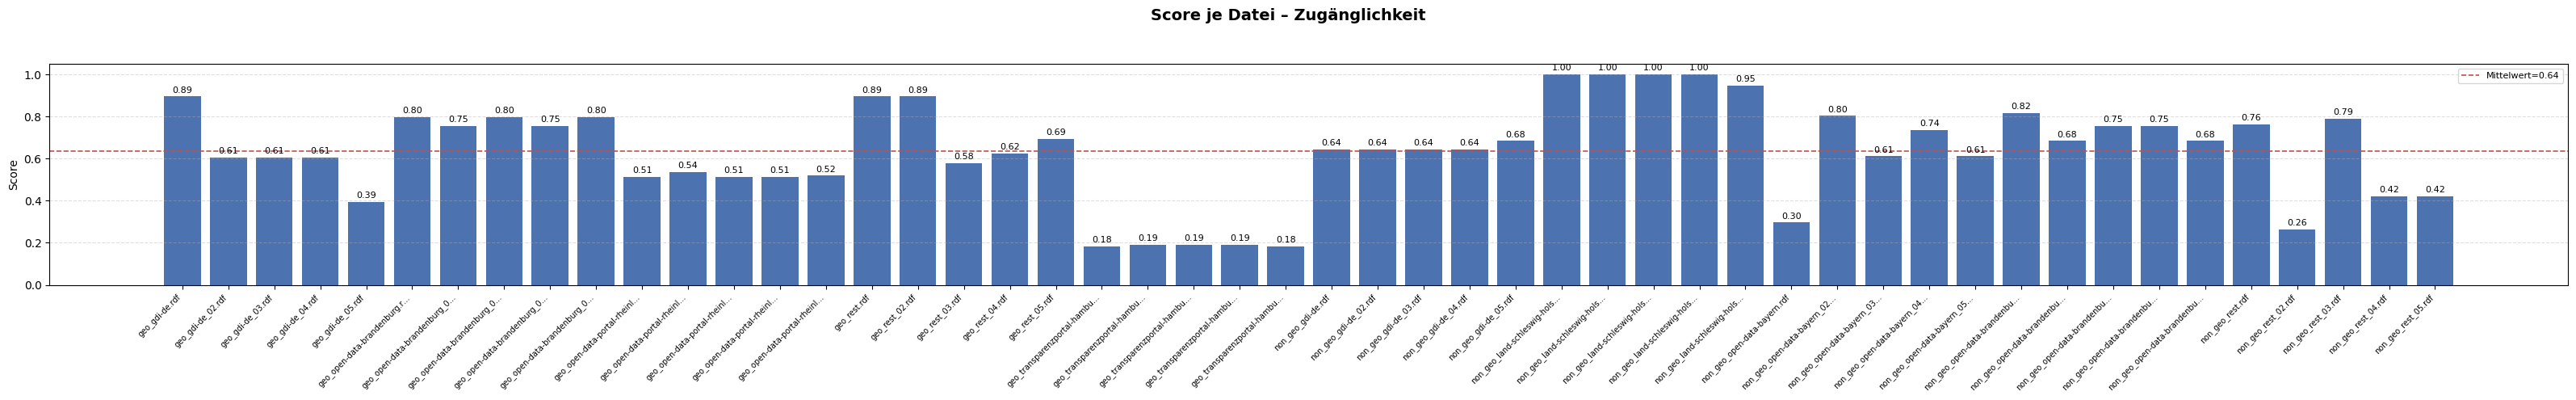

In [31]:
# 4/4 — Score je Datei, aufgeteilt: EINE PNG pro Dimension.
# Bei vier aktiven Dimensionen entstehen hier vier Dateien.
for dim in dimensionen:
    werte = [files[n].get("dimension_scores", {}).get(dim) or 0.0 for n in datei_namen]

    # Breite waechst mit der Dateianzahl (wie beim Gesamtscore-Diagramm des
    # Prototyps), damit Balken und Dateinamen lesbar bleiben.
    breite = max(8.0, 0.6 * len(datei_namen) + 2.0)
    fig, ax = plt.subplots(figsize=(breite, 5))
    fig.suptitle(f"Score je Datei – {dim_de(dim)}", fontsize=14, fontweight="bold")

    x = np.arange(len(datei_namen))
    bars = ax.bar(x, werte, color=BALKEN)
    for bar, wert in zip(bars, werte):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{wert:.2f}",
                ha="center", va="bottom", fontsize=8)

    mittel = float(np.mean(werte))
    ax.axhline(mittel, color=AKZENT, linestyle="--", linewidth=1.2, label=f"Mittelwert={mittel:.2f}")
    ax.set_ylabel("Score")
    # Feste Skala 0..1 ueber alle vier Bilder, damit die Dimensionen vergleichbar bleiben.
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels([kuerzen(n) for n in datei_namen], rotation=45, ha="right", fontsize=7)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    fig.tight_layout(rect=(0, 0, 1, 0.94))
    speichern(fig, f"run_scores_je_datei_{dim_slug(dim)}.png")
    plt.show()

In [32]:
print(f"{len(geschrieben)} PNG(s) in {out_dir.relative_to(REPO_ROOT)}:")
for p in geschrieben:
    print(f"  - {p.name}")

7 PNG(s) in run_outputs/run_2026-07-13_13-21-40_state-evaluation-final_EVAL_sonnet4-5/visualisierung_de:
  - run_zusammenfassung.png
  - run_gesamtscore_je_datei.png
  - run_indikator_ergebnisse.png
  - run_scores_je_datei_auffindbarkeit.png
  - run_scores_je_datei_aussagekraft.png
  - run_scores_je_datei_wiederverwendbarkeit.png
  - run_scores_je_datei_zugaenglichkeit.png
